# Online Shoppers — Exploratory Data Analysis

Goal of this notebook: understand the structure of the data, the target signal,
and the feature behaviour, so that the modelling choices in Phase 2 are
grounded in evidence rather than habit.

The questions I want answered before training anything:

1. How imbalanced is the target, and which kind of imbalance handling is
   warranted (class weights, resampling, threshold tuning)?
2. Which features carry visible signal? Are there obvious leak-like features
   (e.g. `PageValues`) that need careful framing?
3. Do conversion rates differ meaningfully by month, weekend, or visitor type?
4. Are there data quality issues — outliers, mass at zero, suspicious
   categorical levels?


## 1. Setup

In [3]:
import sys
from pathlib import Path

# Make src/ importable when running from notebooks/
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import load

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

FIG_DIR = Path("../reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)


In [4]:
df = load()
df.shape


(12330, 18)

## 2. Schema and missingness

Before any plots, confirm dtypes match the dataset description and check for
missing values. The UCI documentation describes 10 numerical and 7 categorical
columns plus the `Revenue` target.

In [5]:
df.dtypes


Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                          str
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                    str
Weekend                       bool
Revenue                       bool
dtype: object

In [6]:
df.isna().sum()


Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [7]:
df.head()


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## 3. Target distribution

The class balance dictates which metrics matter. With ~15% positives, accuracy
is meaningless — I will focus on **PR-AUC**, **calibration**, and
**top-decile precision** in Phase 2.

In [8]:
target_counts = df["Revenue"].value_counts()
target_share = df["Revenue"].value_counts(normalize=True).round(4)

print(target_counts)
print()
print(target_share)


Revenue
False    10422
True      1908
Name: count, dtype: int64

Revenue
False    0.8453
True     0.1547
Name: proportion, dtype: float64


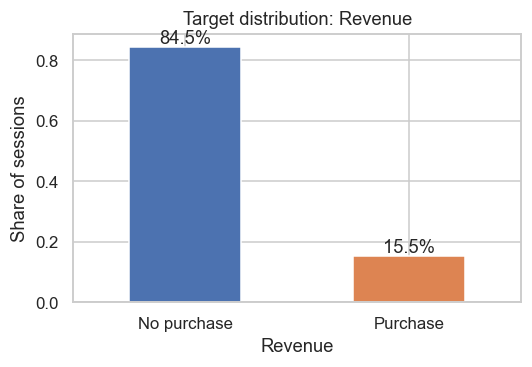

In [9]:
fig, ax = plt.subplots(figsize=(5, 3.5))
target_share.plot(kind="bar", ax=ax, color=["#4c72b0", "#dd8452"])
ax.set_title("Target distribution: Revenue")
ax.set_ylabel("Share of sessions")
ax.set_xticklabels(["No purchase", "Purchase"], rotation=0)
for i, v in enumerate(target_share):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_target_distribution.png")
plt.show()


## 4. Numerical features

Six page-related counters/durations plus four Google-Analytics-style metrics.
A few things I expect to see, based on the UCI description:

- Page-related counters are heavily right-skewed with mass at zero.
- `BounceRates` and `ExitRates` are bounded percentages.
- `PageValues` is the one to watch — it is computed *after* a conversion
  contributes to the page's average value, so it can leak future information
  if used naively. I will discuss this honestly in the modelling phase rather
  than dropping it silently.

In [10]:
numerical_cols = [
    "Administrative", "Administrative_Duration",
    "Informational", "Informational_Duration",
    "ProductRelated", "ProductRelated_Duration",
    "BounceRates", "ExitRates",
    "PageValues", "SpecialDay",
]

df[numerical_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315166,3.321784,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12330.0,80.818611,176.779107,0.0,0.000000,7.500000,93.256250,3398.750000
Informational,12330.0,0.503569,1.270156,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12330.0,34.472398,140.749294,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12330.0,31.731468,44.475503,0.0,7.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12330.0,1194.746220,1913.669288,0.0,184.137500,598.936905,1464.157214,63973.522230
BounceRates,12330.0,0.022191,0.048488,0.0,0.000000,0.003112,0.016813,0.200000
ExitRates,12330.0,0.043073,0.048597,0.0,0.014286,0.025156,0.050000,0.200000
PageValues,12330.0,5.889258,18.568437,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12330.0,0.061427,0.198917,0.0,0.000000,0.000000,0.000000,1.000000


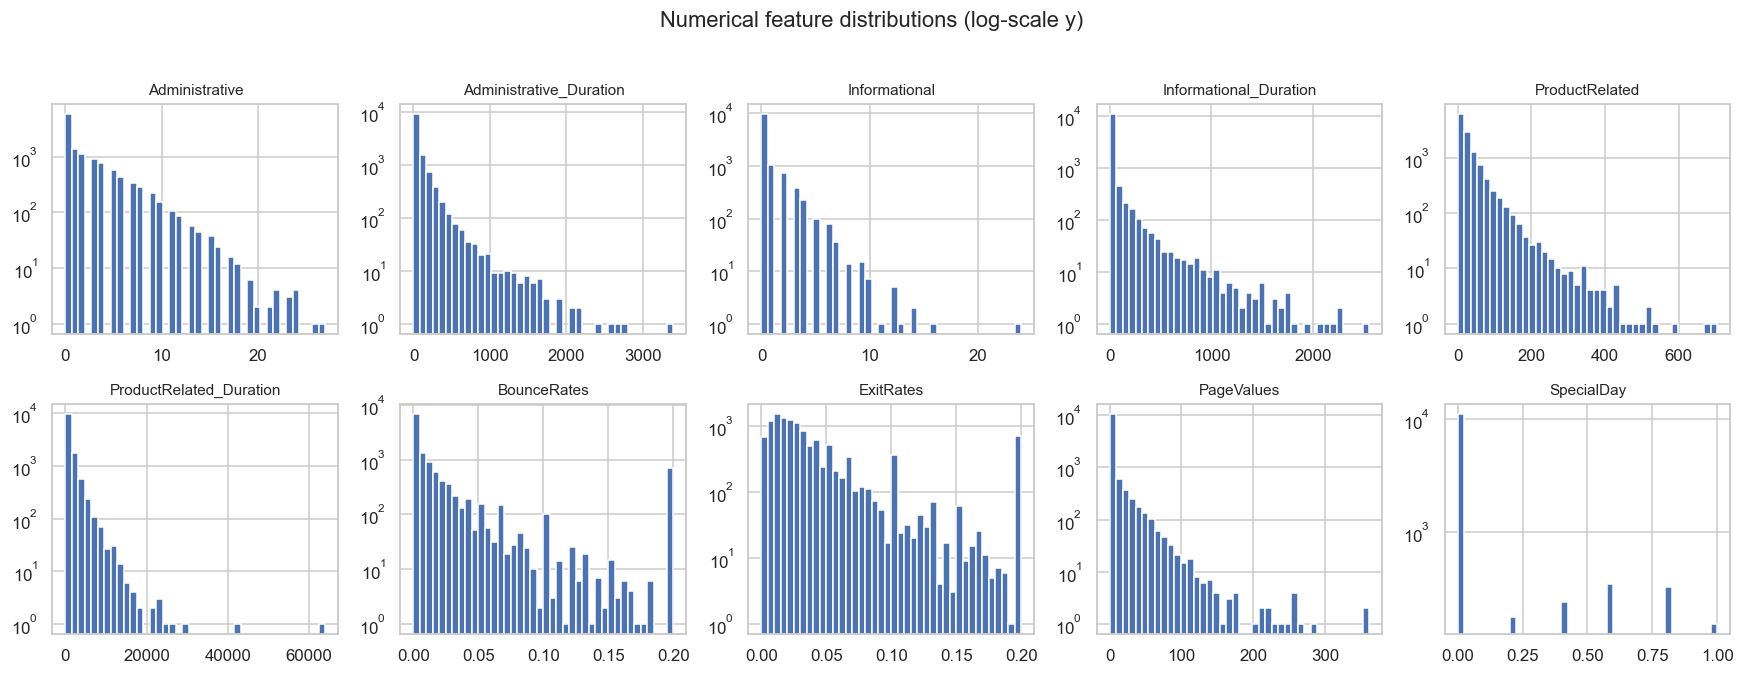

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
for ax, col in zip(axes.flat, numerical_cols):
    ax.hist(df[col], bins=40, color="#4c72b0", edgecolor="white")
    ax.set_title(col, fontsize=10)
    ax.set_yscale("log")
fig.suptitle("Numerical feature distributions (log-scale y)", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "02_numerical_distributions.png", bbox_inches="tight")
plt.show()


### Numerical features by target

Density plots conditioned on `Revenue` show which features separate the two
classes. The clearest separation should appear in `PageValues` and the
`*_Duration` features.

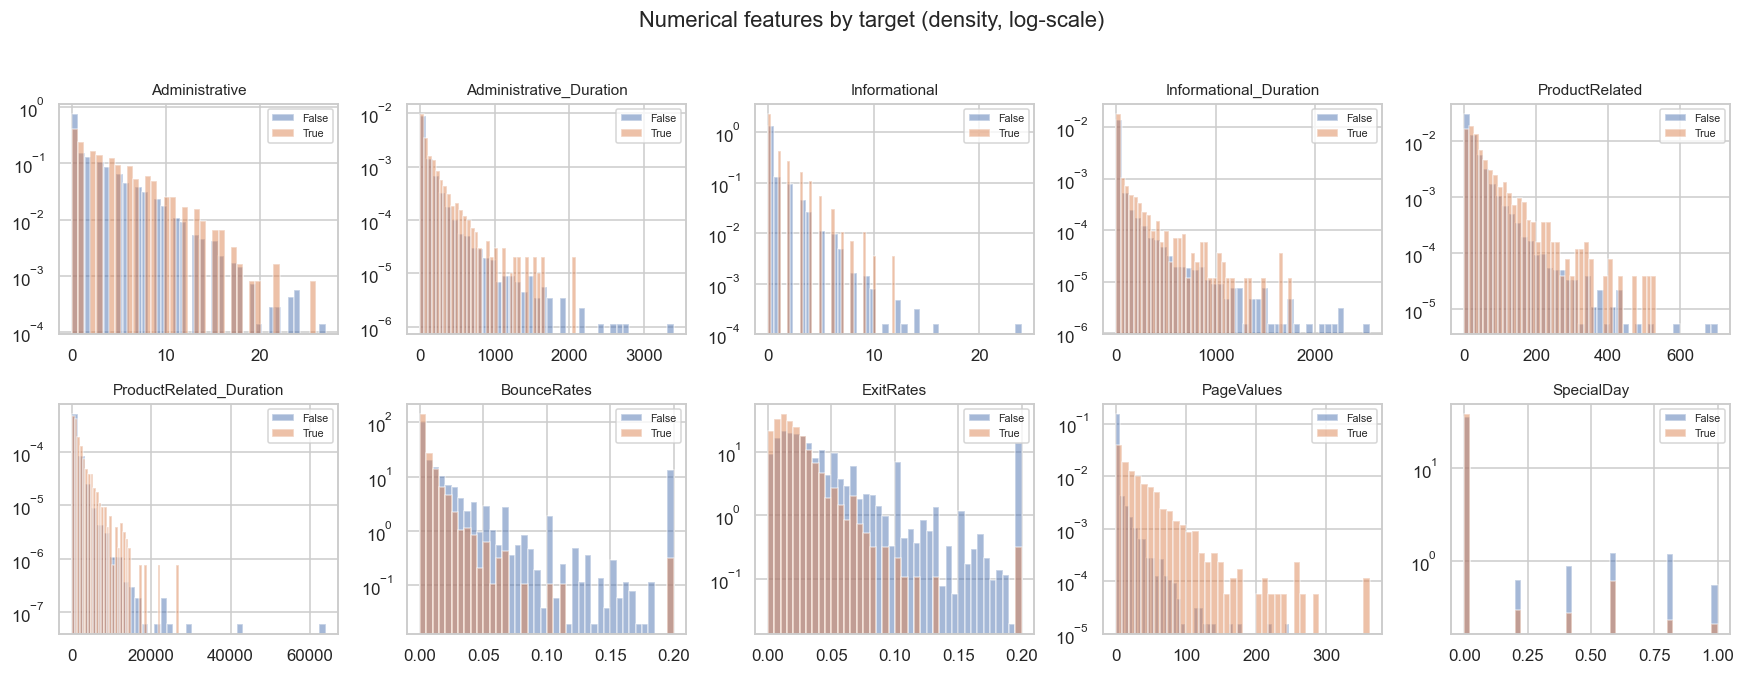

In [12]:
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
for ax, col in zip(axes.flat, numerical_cols):
    for label, sub in df.groupby("Revenue"):
        ax.hist(
            sub[col],
            bins=40,
            density=True,
            alpha=0.5,
            label=str(label),
            log=True,
        )
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=7)
fig.suptitle("Numerical features by target (density, log-scale)", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "03_numerical_by_target.png", bbox_inches="tight")
plt.show()


## 5. Categorical features

`Month`, `VisitorType`, `Weekend`, plus integer-coded `OperatingSystems`,
`Browser`, `Region`, `TrafficType`. The integer-coded ones are nominal (UCI
docs confirm this), so they should be treated as categories, not ordinals.

In [13]:
categorical_cols = [
    "Month", "VisitorType", "Weekend",
    "OperatingSystems", "Browser", "Region", "TrafficType",
]

for col in categorical_cols:
    print(f"--- {col} ({df[col].nunique()} unique) ---")
    print(df[col].value_counts().head(8))
    print()


--- Month (10 unique) ---
Month
May    3364
Nov    2998
Mar    1907
Dec    1727
Oct     549
Sep     448
Aug     433
Jul     432
Name: count, dtype: int64

--- VisitorType (3 unique) ---
VisitorType
Returning_Visitor    10551
New_Visitor           1694
Other                   85
Name: count, dtype: int64

--- Weekend (2 unique) ---
Weekend
False    9462
True     2868
Name: count, dtype: int64

--- OperatingSystems (8 unique) ---
OperatingSystems
2    6601
1    2585
3    2555
4     478
8      79
6      19
7       7
5       6
Name: count, dtype: int64

--- Browser (13 unique) ---
Browser
2     7961
1     2462
4      736
5      467
6      174
10     163
8      135
3      105
Name: count, dtype: int64

--- Region (9 unique) ---
Region
1    4780
3    2403
4    1182
2    1136
6     805
7     761
9     511
8     434
Name: count, dtype: int64

--- TrafficType (20 unique) ---
TrafficType
2     3913
1     2451
3     2052
4     1069
13     738
10     450
6      444
8      343
Name: count, dtype: i

### Conversion rate by category

This is the chart hiring managers actually care about. For each category I
plot the share of sessions that ended in a purchase, with the overall base
rate as a reference line.

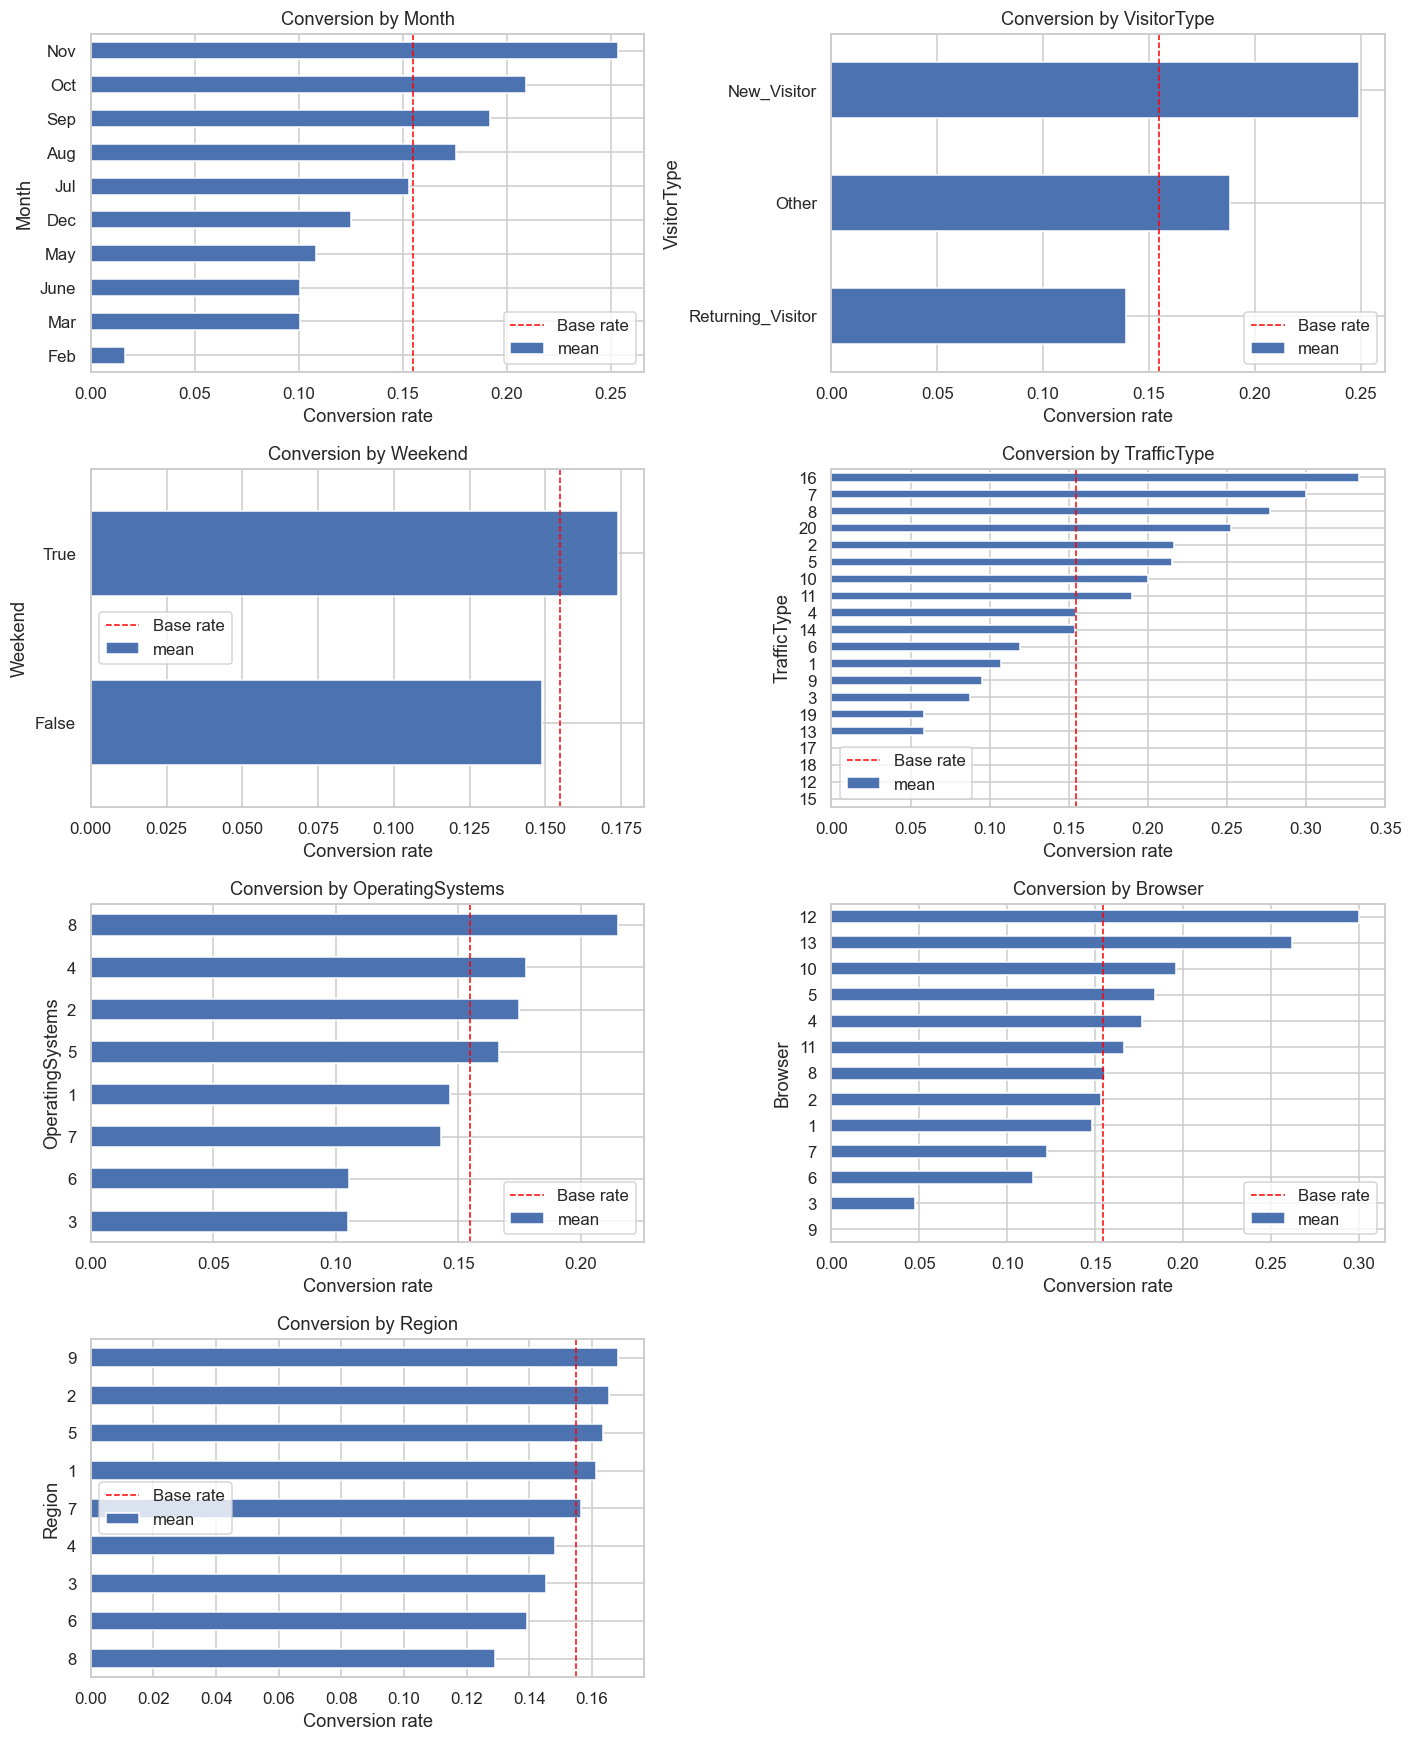

In [14]:
def conversion_by(col, ax):
    g = df.groupby(col)["Revenue"].agg(["mean", "count"]).sort_values("mean")
    g["mean"].plot(kind="barh", ax=ax, color="#4c72b0")
    ax.axvline(df["Revenue"].mean(), color="red", linestyle="--", linewidth=1, label="Base rate")
    ax.set_xlabel("Conversion rate")
    ax.set_title(f"Conversion by {col}")
    ax.legend()


fig, axes = plt.subplots(4, 2, figsize=(13, 16))
plot_cols = ["Month", "VisitorType", "Weekend", "TrafficType",
             "OperatingSystems", "Browser", "Region"]
for ax, col in zip(axes.flat, plot_cols):
    conversion_by(col, ax)
axes.flat[-1].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / "04_conversion_by_category.png", bbox_inches="tight")
plt.show()


## 6. PageValues — the suspicious feature

`PageValues` is documented by Google Analytics as the average value of a page
*for sessions that included it and converted*. That means it is partially
computed from the outcome we're trying to predict. I want to see how strongly
it separates the classes — if it dominates everything else, that's a signal
to either:

- Frame the model as a real-time scoring system that uses `PageValues` from
  *prior* sessions only (acceptable in production), or
- Build a second model without `PageValues` to show what's achievable with
  pre-conversion features only.

Both versions go in the modelling notebook.

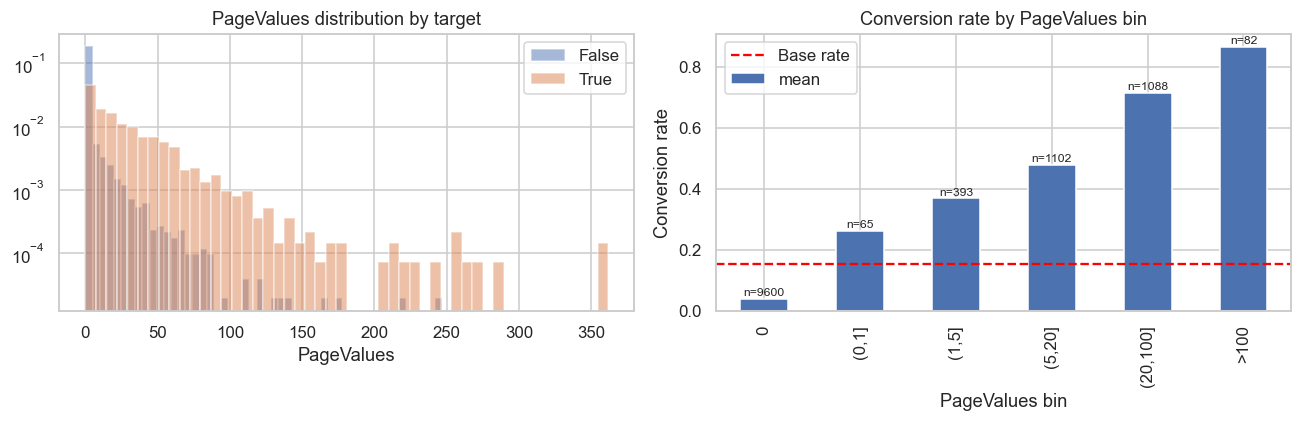

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution
for label, sub in df.groupby("Revenue"):
    axes[0].hist(sub["PageValues"], bins=50, alpha=0.5, label=str(label), density=True)
axes[0].set_yscale("log")
axes[0].set_title("PageValues distribution by target")
axes[0].set_xlabel("PageValues")
axes[0].legend()

# Conversion rate by PageValues bin
df["_pv_bin"] = pd.cut(df["PageValues"],
                       bins=[-0.01, 0, 1, 5, 20, 100, df["PageValues"].max()],
                       labels=["0", "(0,1]", "(1,5]", "(5,20]", "(20,100]", ">100"])
g = df.groupby("_pv_bin", observed=True)["Revenue"].agg(["mean", "count"])
g["mean"].plot(kind="bar", ax=axes[1], color="#4c72b0")
axes[1].axhline(df["Revenue"].mean(), color="red", linestyle="--", label="Base rate")
axes[1].set_title("Conversion rate by PageValues bin")
axes[1].set_ylabel("Conversion rate")
axes[1].set_xlabel("PageValues bin")
axes[1].legend()

# annotate counts
for i, (_, row) in enumerate(g.iterrows()):
    axes[1].text(i, row["mean"] + 0.01, f"n={int(row['count'])}", ha="center", fontsize=8)

df.drop(columns="_pv_bin", inplace=True)

plt.tight_layout()
plt.savefig(FIG_DIR / "05_pagevalues.png", bbox_inches="tight")
plt.show()


## 7. Feature correlations

Spearman rather than Pearson because most features are heavily skewed. I'm
looking for redundant features (the *_Duration / count pairs are almost
certainly correlated) that might warrant feature selection or regularisation
strategy choices in Phase 2.

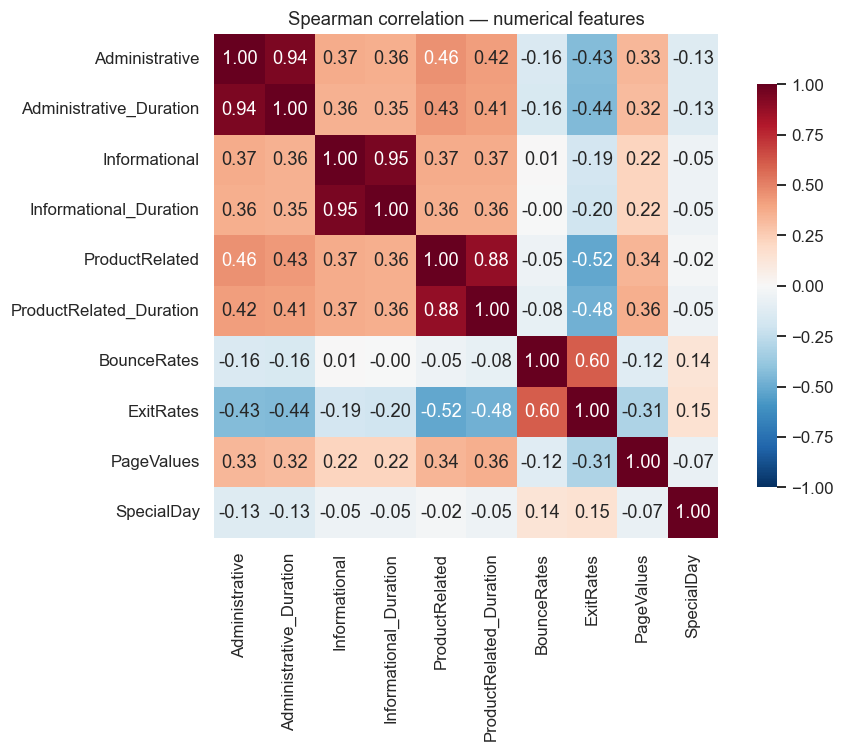

In [16]:
corr = df[numerical_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_title("Spearman correlation — numerical features")
plt.tight_layout()
plt.savefig(FIG_DIR / "06_correlation.png", bbox_inches="tight")
plt.show()


## 8. Data quality checks

A few things I want to confirm before modelling:

- Are there sessions with zero pages visited but non-zero duration? That
  would indicate a logging issue.
- Does `BounceRates` ever exceed `ExitRates`? By definition it shouldn't.
- Are any month abbreviations missing from the data?

In [17]:
# Sessions with zero page visits but non-zero duration
zero_pages_mask = (
    (df["Administrative"] == 0)
    & (df["Informational"] == 0)
    & (df["ProductRelated"] == 0)
)
duration_cols = ["Administrative_Duration", "Informational_Duration", "ProductRelated_Duration"]
suspect = df.loc[zero_pages_mask & (df[duration_cols].sum(axis=1) > 0)]
print(f"Zero pages but non-zero duration: {len(suspect)} rows")

# BounceRates > ExitRates (should not happen by definition)
violations = (df["BounceRates"] > df["ExitRates"]).sum()
print(f"BounceRates > ExitRates: {violations} rows")

# Months present
print("\nMonths present:", sorted(df["Month"].unique()))


Zero pages but non-zero duration: 0 rows
BounceRates > ExitRates: 175 rows

Months present: ['Aug', 'Dec', 'Feb', 'Jul', 'June', 'Mar', 'May', 'Nov', 'Oct', 'Sep']


## 9. Findings

*Filled in after running the notebook locally.* Expected from prior work on
this dataset (Sakar et al. 2018 and others):

- ~15.5% positive class — moderate imbalance, threshold tuning will matter
  more than aggressive resampling.
- `PageValues` is the dominant single feature; needs the leak-vs-real-time
  framing discussed above.
- November and the "Returning_Visitor" segment behave differently from the
  rest; consider interaction features in Phase 2.
- `*_Duration` and the matching count features are strongly correlated;
  consider dropping one side or using a tree-based model that handles
  redundancy gracefully.

These will be confirmed (or revised) when the notebook is executed against
the real data.
